# Escalabilidade — resultados de execução

Lê os logs em `results/escal_forte_*.txt` (escalabilidade forte: tamanho fixo, threads variando) e `results/escal_fraca_*.txt` (escalabilidade fraca: tamanho cresce com as threads), um par por política de scheduling (`static`/`dynamic`/`guided`). Plota tempo, speedup e eficiência vs. número de threads, comparando as três políticas.

In [27]:
import re
import statistics as st
from pathlib import Path

import matplotlib.pyplot as plt

RESULTS_DIR = Path("../results")

FIELD_PATTERNS = {
    "threads_usadas": r"threads_usadas=(\d+)",
    "tempo": r"^tempo=([\d.]+)",
}


def parse_runs(path):
    """Extrai um dict por execucao do ./train encontrada no arquivo
    (o log e' a saida do terminal colada crua -- prompts/comandos de
    shell no meio sao ignorados, o parser so procura os campos)."""
    text = Path(path).read_text()
    starts = [m.start() for m in re.finditer(r"threads_usadas=\d+", text)]
    blocks = [text[s:e] for s, e in zip(starts, starts[1:] + [len(text)])]
    runs = []
    for block in blocks:
        run = {}
        for field, pattern in FIELD_PATTERNS.items():
            m = re.search(pattern, block, re.MULTILINE)
            if m:
                run[field] = int(m.group(1)) if field == "threads_usadas" else float(m.group(1))
        if "threads_usadas" in run and "tempo" in run:
            runs.append(run)
    return runs


def group_by_threads(runs):
    """threads_usadas -> lista de tempos (s), um por execucao repetida."""
    groups = {}
    for r in runs:
        groups.setdefault(r["threads_usadas"], []).append(r["tempo"])
    return dict(sorted(groups.items()))

In [28]:
POLICIES = {
    "static": "tab:blue",
    "dynamic": "tab:orange",
    "guided": "tab:green",
}

STRONG_FILES = {
    "static": "escal_forte_result.txt",
    "dynamic": "escal_forte_dynamic.txt",
    "guided": "escal_forte_guided.txt",
}
WEAK_FILES = {
    "static": "escal_fraca_result.txt",
    "dynamic": "escal_fraca_dynamic.txt",
    "guided": "escal_fraca_guided.txt",
}

strong_groups = {policy: group_by_threads(parse_runs(RESULTS_DIR / fname))
                  for policy, fname in STRONG_FILES.items()}
weak_groups = {policy: group_by_threads(parse_runs(RESULTS_DIR / fname))
               for policy, fname in WEAK_FILES.items()}

for policy, groups in strong_groups.items():
    print(f"forte/{policy}: " + ", ".join(f"p={p} (n={len(v)})" for p, v in groups.items()))
for policy, groups in weak_groups.items():
    print(f"fraca/{policy}: " + ", ".join(f"p={p} (n={len(v)})" for p, v in groups.items()))

forte/static: p=1 (n=10), p=2 (n=10), p=4 (n=10), p=6 (n=10), p=8 (n=10), p=10 (n=10)
forte/dynamic: p=1 (n=10), p=2 (n=10), p=4 (n=10), p=6 (n=10), p=8 (n=10), p=10 (n=10)
forte/guided: p=1 (n=10), p=2 (n=10), p=4 (n=10), p=6 (n=10), p=8 (n=10), p=10 (n=10)
fraca/static: p=1 (n=10), p=2 (n=10), p=4 (n=10), p=6 (n=10), p=8 (n=10), p=10 (n=10)
fraca/dynamic: p=1 (n=10), p=2 (n=10), p=4 (n=10), p=6 (n=10), p=8 (n=10), p=10 (n=10)
fraca/guided: p=1 (n=10), p=2 (n=10), p=4 (n=10), p=6 (n=10), p=8 (n=10), p=10 (n=10)


## Escalabilidade forte

Tamanho do problema fixo (`--ref-size 5000 --batch 32 --iters 3500`), número de threads variando. T1 = mediana das execuções com `threads_usadas=1` (a mesma nos três arquivos, já que a política de schedule não tem efeito com uma única thread). Speedup = T1/Tp, eficiência = speedup/p.

In [ ]:
fig, (ax_s, ax_e) = plt.subplots(1, 2, figsize=(11, 4.5))

for policy, groups in strong_groups.items():
    threads = sorted(groups.keys())
    medians = [st.median(groups[p]) for p in threads]
    T1 = medians[threads.index(1)]
    speedup = [T1 / m for m in medians]
    efficiency = [s / p for s, p in zip(speedup, threads)]
    color = POLICIES[policy]

    # ax_t.plot(threads, medians, "o-", label=policy, color=color)
    ax_s.plot(threads, speedup, "o-", label=policy, color=color)
    ax_e.plot(threads, efficiency, "o-", label=policy, color=color)

# ax_t.set_xlabel("threads"); ax_t.set_ylabel("tempo mediano (s)"); ax_t.set_title("Tempo"); ax_t.legend()

max_p = max(t for g in strong_groups.values() for t in g)
ax_s.plot([1, max_p], [1, max_p], "k--", alpha=0.4, label="ideal (y=p)")
ax_s.set_xlabel("threads"); ax_s.set_ylabel("speedup (T1/Tp)"); ax_s.set_title("Speedup"); ax_s.legend()

ax_e.axhline(1.0, color="k", linestyle="--", alpha=0.4, label="ideal (100%)")
ax_e.set_xlabel("threads"); ax_e.set_ylabel("eficiência (speedup/p)"); ax_e.set_title("Eficiência"); ax_e.legend()
ax_e.set_ylim(0, 1.1)

fig.suptitle("Escalabilidade forte — static vs. dynamic vs. guided")
plt.tight_layout()
plt.show()

### Tabela — escalabilidade forte

In [30]:
print(f"{'policy':<9} {'p':>3} {'mediana(s)':>11} {'stdev':>8} {'speedup':>8} {'eficiência':>11}")
for policy, groups in strong_groups.items():
    threads = sorted(groups.keys())
    T1 = st.median(groups[1])
    for p in threads:
        vals = groups[p]
        med = st.median(vals)
        sd = st.stdev(vals) if len(vals) > 1 else 0.0
        speedup = T1 / med
        eff = speedup / p
        print(f"{policy:<9} {p:>3} {med:>11.3f} {sd:>8.3f} {speedup:>8.2f} {eff:>10.1%}")

policy      p  mediana(s)    stdev  speedup  eficiência
static      1      33.268    0.024     1.00     100.0%
static      2      17.575    0.010     1.89      94.6%
static      4       9.800    0.378     3.39      84.9%
static      6       7.462    0.386     4.46      74.3%
static      8       8.009    0.157     4.15      51.9%
static     10       7.508    0.117     4.43      44.3%
dynamic     1      33.279    0.133     1.00     100.0%
dynamic     2      17.566    0.026     1.89      94.7%
dynamic     4       9.843    0.420     3.38      84.5%
dynamic     6       7.468    0.116     4.46      74.3%
dynamic     8       6.522    0.217     5.10      63.8%
dynamic    10       6.064    0.158     5.49      54.9%
guided      1      33.276    0.028     1.00     100.0%
guided      2      17.584    0.024     1.89      94.6%
guided      4      10.037    0.347     3.32      82.9%
guided      6       7.610    0.197     4.37      72.9%
guided      8       6.525    0.364     5.10      63.7%
guided   

## Escalabilidade fraca

Tamanho do problema cresce com as threads (`--batch 32*p`, `--ref-size 5000 --iters 3500` fixos). Eficiência aqui é T1/Tp direto (sem dividir por p, já que o trabalho por thread já é mantido ~constante).

In [ ]:
fig, ax_e = plt.subplots(figsize=(6, 4.5))

for policy, groups in weak_groups.items():
    threads = sorted(groups.keys())
    medians = [st.median(groups[p]) for p in threads]
    T1 = medians[threads.index(1)]
    efficiency = [T1 / m for m in medians]
    color = POLICIES[policy]

    # ax_t.plot(threads, medians, "o-", label=policy, color=color)
    ax_e.plot(threads, efficiency, "o-", label=policy, color=color)

# ax_t.set_xlabel("threads"); ax_t.set_ylabel("tempo mediano (s)"); ax_t.set_title("Tempo"); ax_t.legend()

ax_e.axhline(1.0, color="k", linestyle="--", alpha=0.4, label="ideal (100%)")
ax_e.set_xlabel("threads"); ax_e.set_ylabel("eficiência (T1/Tp)"); ax_e.set_title("Eficiência"); ax_e.legend()
ax_e.set_ylim(0, 1.1)

fig.suptitle("Escalabilidade fraca — static vs. dynamic vs. guided")
plt.tight_layout()
plt.show()

### Tabela — escalabilidade fraca

In [32]:
print(f"{'policy':<9} {'p':>3} {'batch':>6} {'mediana(s)':>11} {'stdev':>8} {'eficiência':>11}")
for policy, groups in weak_groups.items():
    threads = sorted(groups.keys())
    T1 = st.median(groups[1])
    for p in threads:
        vals = groups[p]
        med = st.median(vals)
        sd = st.stdev(vals) if len(vals) > 1 else 0.0
        eff = T1 / med
        print(f"{policy:<9} {p:>3} {32*p:>6} {med:>11.3f} {sd:>8.3f} {eff:>10.1%}")

policy      p  batch  mediana(s)    stdev  eficiência
static      1     32      33.276    0.084     100.0%
static      2     64      34.948    0.198      95.2%
static      4    128      37.599    1.240      88.5%
static      6    192      37.609    1.756      88.5%
static      8    256      57.285    1.219      58.1%
static     10    320      58.865    1.422      56.5%
dynamic     1     32      33.267    0.020     100.0%
dynamic     2     64      35.106    0.250      94.8%
dynamic     4    128      37.657    1.236      88.3%
dynamic     6    192      38.993    1.637      85.3%
dynamic     8    256      44.584    1.803      74.6%
dynamic    10    320      50.080    1.576      66.4%
guided      1     32      33.291    0.236     100.0%
guided      2     64      34.928    0.019      95.3%
guided      4    128      37.656    0.401      88.4%
guided      6    192      38.616    0.446      86.2%
guided      8    256      44.821    1.087      74.3%
guided     10    320      50.035    1.278    

## Gráfico exigido: eficiência (forte + fraca, `dynamic`)

O speedup da escalabilidade forte com a reta ideal já está no painel "Speedup" da seção de escalabilidade forte acima. Aqui: tempo mediano e eficiência em função do número de threads, cada um com uma curva para a escalabilidade forte e outra para a fraca, na política `dynamic` (a adotada — ver "Balanceamento de carga").

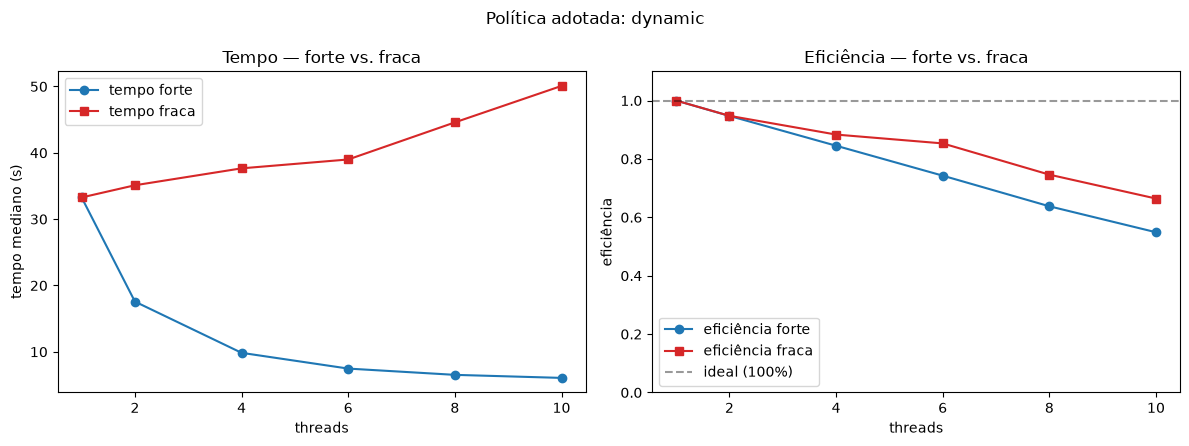

In [33]:
policy = "dynamic"  # politica adotada (ver secao "Balanceamento de carga")

strong = strong_groups[policy]
weak = weak_groups[policy]

strong_threads = sorted(strong.keys())
strong_medians = [st.median(strong[p]) for p in strong_threads]
T1_strong = strong_medians[strong_threads.index(1)]
strong_speedup = [T1_strong / m for m in strong_medians]
strong_efficiency = [s / p for s, p in zip(strong_speedup, strong_threads)]

weak_threads = sorted(weak.keys())
weak_medians = [st.median(weak[p]) for p in weak_threads]
T1_weak = weak_medians[weak_threads.index(1)]
weak_efficiency = [T1_weak / m for m in weak_medians]

fig, (ax_time, ax_eff) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_time.plot(strong_threads, strong_medians, "o-", color="tab:blue", label="tempo forte")
ax_time.plot(weak_threads, weak_medians, "s-", color="tab:red", label="tempo fraca")
ax_time.set_xlabel("threads")
ax_time.set_ylabel("tempo mediano (s)")
ax_time.set_title("Tempo — forte vs. fraca")
ax_time.legend()

ax_eff.plot(strong_threads, strong_efficiency, "o-", color="tab:blue", label="eficiência forte")
ax_eff.plot(weak_threads, weak_efficiency, "s-", color="tab:red", label="eficiência fraca")
ax_eff.axhline(1.0, color="k", linestyle="--", alpha=0.4, label="ideal (100%)")
ax_eff.set_xlabel("threads")
ax_eff.set_ylabel("eficiência")
ax_eff.set_title("Eficiência — forte vs. fraca")
ax_eff.set_ylim(0, 1.1)
ax_eff.legend()

fig.suptitle(f"Política adotada: {policy}")
plt.tight_layout()
plt.show()